In [12]:
"""
NB07_Truth_Propagation_and_Validation

Purpose
-------
1) Propagate the spacecraft state under full SH gravity (DOP853 adaptive).
2) Extract osculating elements (e-vector, semimajor axis, periapsis) from truth.
3) Three-tier validation:
   a) Full-orbit Gauss integral de2d_full vs truth Δe  (first-order theory check)
   b) Gated encounter sum de2d_net vs truth Δe  (capture fraction check)
   c) Truth altitude excursion vs linearized F*||Δe|| predictions
4) Produce validation plots.

Dependencies: NB03 artifact, NB05 artifact, gravity evaluator, scipy
"""

from __future__ import annotations

import json, time, math
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

In [13]:
# ============================================================
# Cell 1 : Auto-discover Artifacts and Config
# ============================================================
ART_DIR = Path("./artifacts")

nb03_files = sorted(ART_DIR.glob("dg_samples_NB03_*_L*.npz"))
nb05_files = sorted(ART_DIR.glob("deltae_NB05_*.npz"))

if not nb03_files:
    raise FileNotFoundError("No NB03 artifact. Run NB03 first.")
if not nb05_files:
    raise FileNotFoundError("No NB05 artifact. Run NB05 first.")

DG_NPZ   = nb03_files[-1]
NB05_NPZ = nb05_files[-1]

RUN_TAG  = datetime.now(timezone.utc).strftime("NB07_%Y%m%dT%H%M%SZ")
OUT_NPZ  = ART_DIR / f"truth_traj_{RUN_TAG}.npz"
OUT_JSON = ART_DIR / f"truth_traj_{RUN_TAG}.json"

try:
    _ti = CONFIG["truth_integrator"]
    INT_METHOD = _ti["method"]; INT_RTOL = _ti["rtol"]; INT_ATOL = _ti["atol"]
except NameError:
    INT_METHOD = "DOP853"; INT_RTOL = 1e-11; INT_ATOL = 1e-12

print(f"NB03 input : {DG_NPZ}")
print(f"NB05 input : {NB05_NPZ}")
print(f"Output     : {OUT_NPZ}")
print(f"Integrator : {INT_METHOD}  rtol={INT_RTOL}  atol={INT_ATOL}")

NB03 input : artifacts\dg_samples_NB03_20260316T033826Z_L200.npz
NB05 input : artifacts\deltae_NB05_20260316T125355Z.npz
Output     : artifacts\truth_traj_NB07_20260316T125856Z.npz
Integrator : DOP853  rtol=1e-11  atol=1e-12


In [14]:
# ============================================================
# Cell 2 : Load Initial State and NB05 Predictions
# ============================================================
dg = np.load(DG_NPZ, allow_pickle=False)

t_grid = dg["t"]
r0 = dg["r_eci"][0].astype(float).copy()
v0 = dg["v_eci"][0].astype(float).copy()

meta_dg = json.loads(str(dg["meta_json"])) if "meta_json" in dg else {}
_op = meta_dg.get("orbit_params", meta_dg.get("orbit_params_from_npz", {}))
omega = float(_op.get("omega_rad_s", _op.get("omega_used_in_nb02", 2.6616995e-6)))
_gm = meta_dg.get("gravity_model", meta_dg.get("gravity_model_from_pds", {}))
mu = float(_gm.get("GM_km3_s2", 4902.800076))
L  = int(_gm.get("L_used", meta_dg.get("L", 200)))

M = t_grid.size
t_span = [float(t_grid[0]), float(t_grid[-1])]

# Load NB05 predictions
nb5 = np.load(NB05_NPZ, allow_pickle=False)
de2d_full_map  = nb5["de2d_full"]             # (2,) full-orbit Gauss integral
de2d_net_map   = nb5["de2d_net"]              # (2,) gated encounter sum
dh_max_full_map = float(nb5["dh_max_full"])    # km
dh_max_net_map  = float(nb5["dh_max_net"])     # km
F_amp           = float(nb5["F_amp"])           # km
p_hat           = nb5["p_hat"]
q_hat           = nb5["q_hat"]
capture_frac    = float(nb5["capture_fraction"])

print(f"Initial state: r0={r0}, v0={v0}")
print(f"mu={mu}, omega={omega:.7e}, L={L}")
print(f"\nNB05 predictions:")
print(f"  Full-orbit: de2d_full=[{de2d_full_map[0]:+.6e}, {de2d_full_map[1]:+.6e}]  ||={np.linalg.norm(de2d_full_map):.6e}  dh={dh_max_full_map*1000:.2f} m")
print(f"  Gated net:  de2d_net =[{de2d_net_map[0]:+.6e}, {de2d_net_map[1]:+.6e}]  ||={np.linalg.norm(de2d_net_map):.6e}  dh={dh_max_net_map*1000:.2f} m")
print(f"  Capture fraction = {capture_frac:.4f}")

Initial state: r0=[1787.4    0.     0. ], v0=[ 0.00000000e+00  1.01412636e-16 -1.65619403e+00]
mu=4902.79996708864, omega=2.6616995e-06, L=200

NB05 predictions:
  Full-orbit: de2d_full=[+3.490250e-05, +2.759606e-04]  ||=2.781591e-04  dh=497.18 m
  Gated net:  de2d_net =[+4.944666e-05, +1.296426e-05]  ||=5.111794e-05  dh=91.37 m
  Capture fraction = 0.1838


In [15]:
# ============================================================
# Cell 3 : Ensure Gravity Evaluator + Frame Transforms
# ============================================================
_need_grav = False
try:
    _ = gravity_accel_sph_harm; _ = sh
    print("Gravity evaluator found in namespace.")
except NameError:
    print("Loading gravity evaluator inline...")
    _need_grav = True

if _need_grav:
    from dataclasses import dataclass
    try:
        from numba import njit
    except ImportError:
        def njit(*a, **kw):
            def w(fn): return fn
            if len(a)==1 and callable(a[0]): return a[0]
            return w

    MODEL_DIR = Path("./gravity_models")
    LOCAL_SHA_PATH = MODEL_DIR / "gggrx_0900c_sha.tab"
    if not LOCAL_SHA_PATH.exists():
        raise FileNotFoundError(f"Missing {LOCAL_SHA_PATH}. Run NB01 first.")

    @dataclass
    class SHModel:
        C: np.ndarray; S: np.ndarray; sigmaC: np.ndarray; sigmaS: np.ndarray
        Lmax: int; mu_km3_s2: float; Rref_km: float; normalized: bool; source: str

    def parse_gggrx_pds3_fixed(path):
        lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
        parts = [p.strip() for p in lines[0].split(",") if p.strip()]
        Rref_km=float(parts[0]); mu_km3_s2=float(parts[1])
        Lmax=int(float(parts[3])); normalized=(int(float(parts[5]))==1)
        C=np.zeros((Lmax+1,Lmax+1)); S=np.zeros_like(C)
        sigmaC=np.zeros_like(C); sigmaS=np.zeros_like(C)
        for ln in lines[2:]:
            if not ln.strip() or len(ln)<107: continue
            try:
                l=int(ln[0:5]);m=int(ln[6:11])
                C[l,m]=float(ln[12:35]);S[l,m]=float(ln[36:59])
                sigmaC[l,m]=float(ln[60:83]);sigmaS[l,m]=float(ln[84:107])
            except: continue
        if C[0,0]==0.0: C[0,0]=1.0
        return SHModel(C=C,S=S,sigmaC=sigmaC,sigmaS=sigmaS,Lmax=Lmax,
                       mu_km3_s2=mu_km3_s2,Rref_km=Rref_km,normalized=normalized,source=str(path))

    sh = parse_gggrx_pds3_fixed(LOCAL_SHA_PATH)

    @njit(cache=True)
    def _fully_normalized_legendre(sin_phi,cos_phi,L):
        Pbar=np.zeros((L+1,L+1));dPbar=np.zeros((L+1,L+1));Pbar[0,0]=1.0
        for m in range(1,L+1):
            fac=math.sqrt((2.*m+1.)/(2.*m))
            Pbar[m,m]=cos_phi*fac*Pbar[m-1,m-1]
            dPbar[m,m]=fac*(-sin_phi*Pbar[m-1,m-1]+cos_phi*dPbar[m-1,m-1])
        for m in range(0,L):
            fac=math.sqrt(2.*m+3.)
            Pbar[m+1,m]=sin_phi*fac*Pbar[m,m]
            dPbar[m+1,m]=fac*(cos_phi*Pbar[m,m]+sin_phi*dPbar[m,m])
        for m in range(0,L+1):
            for l in range(m+2,L+1):
                ls=float(l);ms=float(m)
                a=math.sqrt((4.*ls*ls-1.)/(ls*ls-ms*ms))
                b=math.sqrt(((ls-1.)**2-ms*ms)/(4.*(ls-1.)**2-1.))
                Pbar[l,m]=a*(sin_phi*Pbar[l-1,m]-b*Pbar[l-2,m])
                dPbar[l,m]=a*(cos_phi*Pbar[l-1,m]+sin_phi*dPbar[l-1,m]-b*dPbar[l-2,m])
        return Pbar,dPbar

    EPS_POLE=1e-10

    @njit(cache=True)
    def _sh_summation(C,S,Pbar,dP,L,mu,a_ref,r,lam,sin_phi,cos_phi):
        cosml=np.empty(L+1);sinml=np.empty(L+1);cosml[0]=1.;sinml[0]=0.
        c1=math.cos(lam);s1=math.sin(lam)
        for m in range(1,L+1):
            cosml[m]=cosml[m-1]*c1-sinml[m-1]*s1
            sinml[m]=sinml[m-1]*c1+cosml[m-1]*s1
        rho=a_ref/r;ar=0.;ap=0.;al=0.;rho_l=1.
        for l in range(0,L+1):
            if l>0:rho_l*=rho
            sV=0.;sd=0.;sl=0.
            for m in range(0,l+1):
                t=C[l,m]*cosml[m]+S[l,m]*sinml[m]
                sV+=Pbar[l,m]*t;sd+=dP[l,m]*t
                if m>0:sl+=Pbar[l,m]*m*(-C[l,m]*sinml[m]+S[l,m]*cosml[m])
            ar+=(l+1)*rho_l*sV;ap+=rho_l*sd;al+=rho_l*sl
        r2=r*r
        return -(mu/r2)*ar,-(mu/r2)*ap,-(mu/r2)*(al/cos_phi)

    def gravity_accel_sph_harm(sh,r_bf,degree=50):
        x,y,z=float(r_bf[0]),float(r_bf[1]),float(r_bf[2])
        r=math.sqrt(x*x+y*y+z*z);lam=math.atan2(y,x);sp=z/r
        cp=math.sqrt(max(0.,1.-sp*sp))
        if cp<EPS_POLE:sp=math.copysign(math.sqrt(1.-EPS_POLE**2),sp);cp=EPS_POLE
        Ld=min(int(degree),sh.Lmax)
        P,dP=_fully_normalized_legendre(sp,cp,Ld)
        ar,ap,al=_sh_summation(sh.C,sh.S,P,dP,Ld,sh.mu_km3_s2,sh.Rref_km,r,lam,sp,cp)
        cl=math.cos(lam);sl=math.sin(lam)
        return np.array([ar*cp*cl+ap*(-sp)*cl+al*(-sl),ar*cp*sl+ap*(-sp)*sl+al*cl,ar*sp+ap*cp])

    print(f"  Loaded: {sh.source}, Lmax={sh.Lmax}")

# Frame transforms (corrected signs)
def _R3(th):
    c=np.cos(th);s=np.sin(th)
    return np.array([[c,-s,0],[s,c,0],[0,0,1.]])
def eci_to_fixed(r,t_s): return _R3(-omega*t_s)@r
def fixed_to_eci(v,t_s): return _R3(+omega*t_s)@v

print(f"Using degree L = {L}")

Gravity evaluator found in namespace.
Using degree L = 200


In [16]:
# ============================================================
# Cell 4 : Propagate with DOP853
# ============================================================
def eom(t_sec, y):
    r_mf = eci_to_fixed(y[:3], t_sec)
    g_mf = gravity_accel_sph_harm(sh, r_mf, degree=L)
    g_eci = fixed_to_eci(g_mf, t_sec)
    return np.concatenate([y[3:], g_eci])

y0 = np.concatenate([r0, v0])
t_eval = t_grid.astype(float)

print(f"Propagating with {INT_METHOD}...")
t0 = time.time()
sol = solve_ivp(eom, t_span, y0, method=INT_METHOD, t_eval=t_eval,
                rtol=INT_RTOL, atol=INT_ATOL, dense_output=True)
elapsed = time.time() - t0

if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

r_truth = sol.y[:3].T
v_truth = sol.y[3:].T
rnorm_truth = np.linalg.norm(r_truth, axis=1)

print(f"Done in {elapsed:.1f}s  ({sol.nfev} evals)")
print(f"r [km]: min={rnorm_truth.min():.6f}  max={rnorm_truth.max():.6f}")
print(f"Altitude excursion: {(rnorm_truth.max()-rnorm_truth.min())*1000:.2f} m")

Propagating with DOP853...
Done in 1.5s  (6941 evals)
r [km]: min=1787.313889  max=1790.040234
Altitude excursion: 2726.34 m


In [17]:
# ============================================================
# Cell 5 : Extract Osculating Elements from Truth
# ============================================================
# Eccentricity vector
hvec_t = np.cross(r_truth, v_truth)
vxh_t  = np.cross(v_truth, hvec_t)
evec_t = vxh_t / mu - r_truth / rnorm_truth[:, None]

# Project into fixed (p, q) basis
ep_truth = evec_t @ p_hat
eq_truth = evec_t @ q_hat

# Net Δe over one orbit
de_p_truth = ep_truth[-1] - ep_truth[0]
de_q_truth = eq_truth[-1] - eq_truth[0]
de2d_truth = np.array([de_p_truth, de_q_truth])
de2d_truth_norm = np.linalg.norm(de2d_truth)
dh_truth_de = F_amp * de2d_truth_norm  # linearized dh from truth Δe

# Osculating semimajor axis and periapsis
vnorm_t = np.linalg.norm(v_truth, axis=1)
energy_t = 0.5 * vnorm_t**2 - mu / rnorm_truth  # specific energy
a_osc = -mu / (2.0 * energy_t)                   # osculating a
e_osc = np.linalg.norm(evec_t, axis=1)            # osculating |e|
rp_osc = a_osc * (1.0 - e_osc)                    # osculating periapsis radius

# Direct altitude excursion
dr_truth_direct = (rnorm_truth.max() - rnorm_truth.min())  # km

print(f"Truth osculating eccentricity (p,q basis):")
print(f"  e(t=0) = [{ep_truth[0]:+.6e}, {eq_truth[0]:+.6e}]")
print(f"  e(t=T) = [{ep_truth[-1]:+.6e}, {eq_truth[-1]:+.6e}]")
print(f"  Δe_truth = [{de_p_truth:+.6e}, {de_q_truth:+.6e}]")
print(f"  ||Δe_truth|| = {de2d_truth_norm:.6e}")
print(f"  F*||Δe_truth|| = {dh_truth_de*1000:.2f} m")
print(f"\nOsculating orbit:")
print(f"  a: {a_osc.min():.4f} to {a_osc.max():.4f} km  (Δa = {(a_osc.max()-a_osc.min())*1000:.2f} m)")
print(f"  |e|: {e_osc.min():.6e} to {e_osc.max():.6e}")
print(f"  r_p: {rp_osc.min():.4f} to {rp_osc.max():.4f} km")
print(f"  Direct r excursion: {dr_truth_direct*1000:.2f} m")

Truth osculating eccentricity (p,q basis):
  e(t=0) = [+2.221411e-08, +0.000000e+00]
  e(t=T) = [+3.291512e-05, +2.733402e-04]
  Δe_truth = [+3.289291e-05, +2.733402e-04]
  ||Δe_truth|| = 2.753122e-04
  F*||Δe_truth|| = 492.09 m

Osculating orbit:
  a: 1787.3618 to 1788.6605 km  (Δa = 1298.70 m)
  |e|: 2.221411e-08 to 1.527794e-03
  r_p: 1784.6452 to 1787.4196 km
  Direct r excursion: 2726.34 m


In [18]:
# ============================================================
# Cell 6 : Three-Tier Validation Table
# ============================================================
de2d_full_map_norm = float(np.linalg.norm(de2d_full_map))
de2d_net_map_norm  = float(np.linalg.norm(de2d_net_map))

# Relative errors
re_full_p = abs(de2d_full_map[0] - de_p_truth) / max(abs(de_p_truth), 1e-30)
re_full_q = abs(de2d_full_map[1] - de_q_truth) / max(abs(de_q_truth), 1e-30)
re_full_norm = abs(de2d_full_map_norm - de2d_truth_norm) / max(de2d_truth_norm, 1e-30)
re_full_dh = abs(dh_max_full_map - dh_truth_de) / max(dh_truth_de, 1e-30)

re_net_norm = abs(de2d_net_map_norm - de2d_truth_norm) / max(de2d_truth_norm, 1e-30)

print(f"{'='*80}")
print(f"  TIER 1: Full-Orbit Gauss Integral vs Truth (first-order theory check)")
print(f"{'='*80}")
print(f"  {'Quantity':<20s}  {'Full-orbit map':>14s}  {'Truth':>14s}  {'Rel Err':>10s}")
print(f"  {'-'*20}  {'-'*14}  {'-'*14}  {'-'*10}")
print(f"  {'de_p':<20s}  {de2d_full_map[0]:+14.6e}  {de_p_truth:+14.6e}  {re_full_p:10.4f}")
print(f"  {'de_q':<20s}  {de2d_full_map[1]:+14.6e}  {de_q_truth:+14.6e}  {re_full_q:10.4f}")
print(f"  {'||de2d||':<20s}  {de2d_full_map_norm:14.6e}  {de2d_truth_norm:14.6e}  {re_full_norm:10.4f}")
print(f"  {'F*||de|| [m]':<20s}  {dh_max_full_map*1000:14.2f}  {dh_truth_de*1000:14.2f}  {re_full_dh:10.4f}")

print(f"\n  >>> First-order theory relative error in ||Δe||: {re_full_norm*100:.2f}%")

print(f"\n{'='*80}")
print(f"  TIER 2: Gated Encounter Sum vs Full-Orbit (capture check)")
print(f"{'='*80}")
print(f"  Gated ||de2d_net||   = {de2d_net_map_norm:.6e}")
print(f"  Full  ||de2d_full||  = {de2d_full_map_norm:.6e}")
print(f"  Capture fraction     = {capture_frac:.4f}  ({capture_frac*100:.1f}%)")
print(f"  Gated vs truth error = {re_net_norm*100:.1f}%")

print(f"\n{'='*80}")
print(f"  TIER 3: Altitude Excursion Comparison")
print(f"{'='*80}")
print(f"  F*||de_full|| (linearized)    = {dh_max_full_map*1000:.2f} m")
print(f"  F*||de_truth|| (truth de)     = {dh_truth_de*1000:.2f} m")
print(f"  Truth r excursion (max-min)   = {dr_truth_direct*1000:.2f} m")
print(f"  Truth Δa excursion            = {(a_osc.max()-a_osc.min())*1000:.2f} m")
print(f"")
print(f"  Note: r excursion includes semimajor-axis oscillation + eccentricity")
print(f"  effects. F*||Δe|| captures only the eccentricity-driven component.")

  TIER 1: Full-Orbit Gauss Integral vs Truth (first-order theory check)
  Quantity              Full-orbit map           Truth     Rel Err
  --------------------  --------------  --------------  ----------
  de_p                   +3.490250e-05   +3.289291e-05      0.0611
  de_q                   +2.759606e-04   +2.733402e-04      0.0096
  ||de2d||                2.781591e-04    2.753122e-04      0.0103
  F*||de|| [m]                  497.18          492.09      0.0103

  >>> First-order theory relative error in ||Δe||: 1.03%

  TIER 2: Gated Encounter Sum vs Full-Orbit (capture check)
  Gated ||de2d_net||   = 5.111794e-05
  Full  ||de2d_full||  = 2.781591e-04
  Capture fraction     = 0.1838  (18.4%)
  Gated vs truth error = 81.4%

  TIER 3: Altitude Excursion Comparison
  F*||de_full|| (linearized)    = 497.18 m
  F*||de_truth|| (truth de)     = 492.09 m
  Truth r excursion (max-min)   = 2726.34 m
  Truth Δa excursion            = 1298.70 m

  Note: r excursion includes semimajor-axis

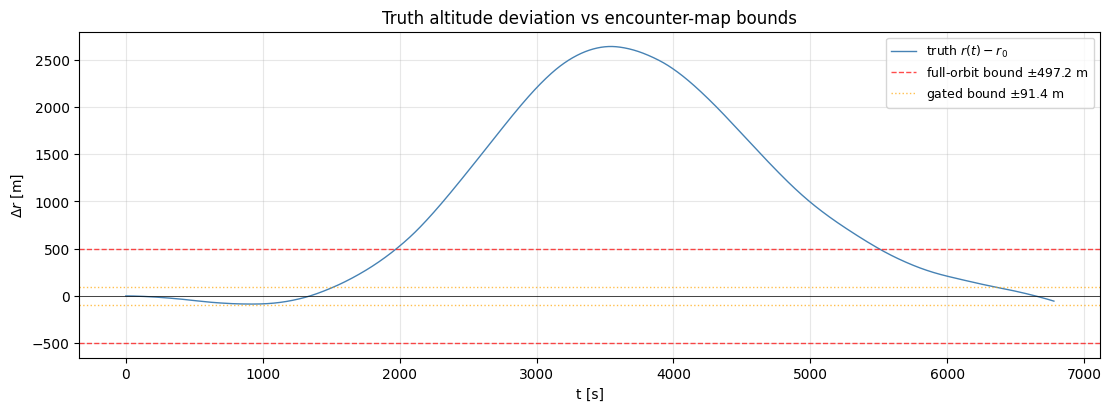

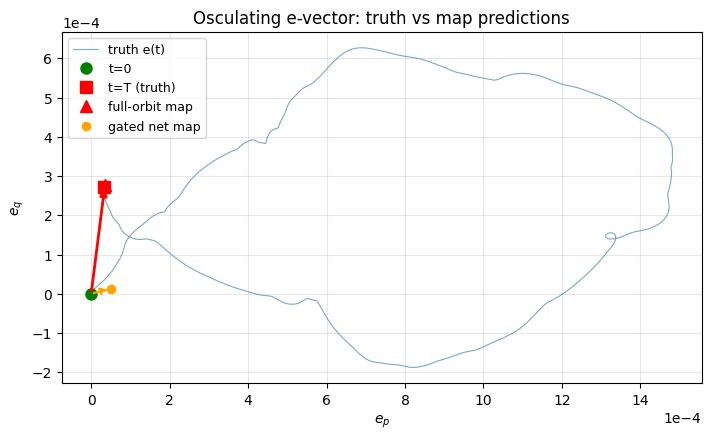

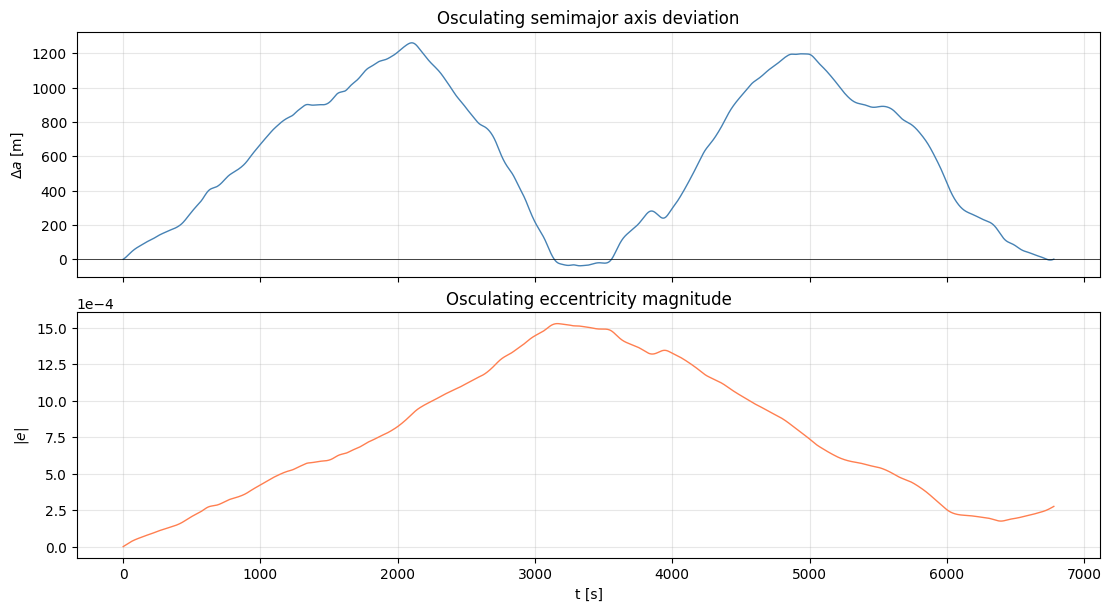

In [19]:
# ============================================================
# Cell 7 : Validation Plots
# ============================================================
a_nom = rnorm_truth[0]

# --- Plot 1: Truth altitude deviation + bounds ---
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ax.plot(t_grid, (rnorm_truth - a_nom)*1000, lw=1.0, color="steelblue", label="truth $r(t)-r_0$")
ax.axhline(0, color="k", lw=0.5)
ax.axhline(+dh_max_full_map*1000, color="red", ls="--", lw=1.0, alpha=0.7,
           label=f"full-orbit bound $\\pm${dh_max_full_map*1000:.1f} m")
ax.axhline(-dh_max_full_map*1000, color="red", ls="--", lw=1.0, alpha=0.7)
ax.axhline(+dh_max_net_map*1000, color="orange", ls=":", lw=1.0, alpha=0.7,
           label=f"gated bound $\\pm${dh_max_net_map*1000:.1f} m")
ax.axhline(-dh_max_net_map*1000, color="orange", ls=":", lw=1.0, alpha=0.7)
ax.set_xlabel("t [s]"); ax.set_ylabel("$\\Delta r$ [m]")
ax.set_title("Truth altitude deviation vs encounter-map bounds")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
plt.show()

# --- Plot 2: Osculating e(t) in (p,q) plane ---
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.plot(ep_truth, eq_truth, lw=0.8, color="steelblue", alpha=0.7, label="truth e(t)")
ax.plot(ep_truth[0], eq_truth[0], "go", ms=8, label="t=0")
ax.plot(ep_truth[-1], eq_truth[-1], "rs", ms=8, label="t=T (truth)")
# Full-orbit map prediction
end_full = de2d_full_map + [ep_truth[0], eq_truth[0]]
ax.annotate("", xy=end_full, xytext=[ep_truth[0], eq_truth[0]],
            arrowprops=dict(arrowstyle="-|>", color="red", lw=2))
ax.plot(*end_full, "r^", ms=8, label="full-orbit map")
# Gated net prediction
end_net = de2d_net_map + [ep_truth[0], eq_truth[0]]
ax.annotate("", xy=end_net, xytext=[ep_truth[0], eq_truth[0]],
            arrowprops=dict(arrowstyle="-|>", color="orange", lw=1.5, ls="--"))
ax.plot(*end_net, "o", color="orange", ms=6, label="gated net map")
ax.set_xlabel(r"$e_p$"); ax.set_ylabel(r"$e_q$")
ax.set_title("Osculating e-vector: truth vs map predictions")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.ticklabel_format(style="scientific", scilimits=(-4,-4))
plt.show()

# --- Plot 3: Osculating a(t) and |e|(t) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True, sharex=True)
ax1.plot(t_grid, (a_osc - a_osc[0])*1000, lw=1.0, color="steelblue")
ax1.set_ylabel("$\\Delta a$ [m]"); ax1.set_title("Osculating semimajor axis deviation")
ax1.grid(True, alpha=0.3); ax1.axhline(0, color="k", lw=0.5)
ax2.plot(t_grid, e_osc, lw=1.0, color="coral")
ax2.set_xlabel("t [s]"); ax2.set_ylabel("$|e|$")
ax2.set_title("Osculating eccentricity magnitude")
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis="y", style="scientific", scilimits=(-4,-4))
plt.show()

In [20]:
# ============================================================
# Cell 8 : Save Artifacts
# ============================================================
meta = {
    "run_tag": RUN_TAG, "dg_npz": str(DG_NPZ), "nb05_npz": str(NB05_NPZ),
    "mu_km3_s2": mu, "omega_rad_s": omega, "L": L,
    "integrator": f"{INT_METHOD}, rtol={INT_RTOL}, atol={INT_ATOL}",
    "nfev": int(sol.nfev), "elapsed_s": round(elapsed, 2),
    "validation": {
        "tier1_full_orbit": {
            "de_full_map": de2d_full_map.tolist(),
            "de_truth":    de2d_truth.tolist(),
            "norm_map":    de2d_full_map_norm,
            "norm_truth":  de2d_truth_norm,
            "rel_err":     re_full_norm,
            "dh_map_m":    dh_max_full_map * 1000,
            "dh_truth_m":  dh_truth_de * 1000,
        },
        "tier2_gated": {
            "de_net_map":     de2d_net_map.tolist(),
            "norm_net":       de2d_net_map_norm,
            "capture_frac":   capture_frac,
            "rel_err_vs_truth": re_net_norm,
        },
        "tier3_altitude": {
            "dh_full_map_m":   dh_max_full_map * 1000,
            "dh_truth_de_m":   dh_truth_de * 1000,
            "dr_truth_m":      dr_truth_direct * 1000,
            "da_excursion_m":  (a_osc.max() - a_osc.min()) * 1000,
        },
    },
}

np.savez(OUT_NPZ, t=t_grid, r_eci=r_truth, v_eci=v_truth, rnorm=rnorm_truth,
         ep_truth=ep_truth, eq_truth=eq_truth, de2d_truth=de2d_truth,
         a_osc=a_osc, e_osc=e_osc, rp_osc=rp_osc,
         de2d_full_map=de2d_full_map, de2d_net_map=de2d_net_map,
         meta_json=json.dumps(meta))

OUT_JSON.write_text(json.dumps({"meta": meta}, indent=2), encoding="utf-8")

print(f"Saved: {OUT_NPZ}")
print(f"Saved: {OUT_JSON}")
print(f"\n--- NB07 complete ---")

Saved: artifacts\truth_traj_NB07_20260316T125856Z.npz
Saved: artifacts\truth_traj_NB07_20260316T125856Z.json

--- NB07 complete ---
